In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
import scipy as sci
import pandas as pd
import soundfile as sf
from IPython.display import Audio, display
from scipy.signal import stft


5. Importer signalet ‘TelephoneDialup’ og bestem, hvilke DTMF-frekvenser (slå
dem op) de enkelte cifre skal indeholde? Lav DFT på signalet, og identificer
DTMF-tonerne på frekvensspektret. Hvilket telefonnummer er der tale om?


Sample rate: 48000 Hz
Number of samples: 372096
Duration: 7.75 seconds


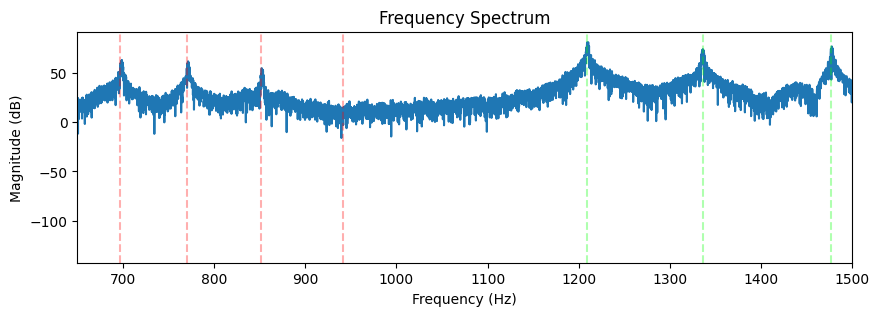

In [14]:
# Load audio file
import soundfile as sf

audio, f_s = sf.read('TelephoneDialup.mp3')

"""
DTMF-frekvenser
1: 697 Hz + 1209 Hz
2: 697 Hz + 1336 Hz
3: 697 Hz + 1477 Hz
4: 770 Hz + 1209 Hz
5: 770 Hz + 1336 Hz
6: 770 Hz + 1477 Hz
7: 852 Hz + 1209 Hz
8: 852 Hz + 1336 Hz
9: 852 Hz + 1477 Hz
*: 941 Hz + 1209 Hz
0: 941 Hz + 1336 Hz
#: 941 Hz + 1477 Hz
"""


print(f'Sample rate: {f_s} Hz')
print(f'Number of samples: {len(audio)}')
print(f'Duration: {len(audio)/f_s:.2f} seconds')


x = audio[:, 0]  # Use the first channel of the audio

T_s = 1 / f_s

# Perform FFT analysis
N = len(x)  # Number of samples
X = np.fft.fft(x, N)  # Compute FFT
f = np.fft.fftfreq(N, T_s)  # Frequency axis

# Magnitude spectrum
magnitude = np.abs(X)

plt.figure(figsize=(10, 3))
plt.plot(f[:N//2], 20*np.log10(magnitude[:N//2]))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Frequency Spectrum')
plt.xlim(650, 1500)
plt.axvline(697, color='#ff000050', linestyle='--')
plt.axvline(770, color='#ff000050', linestyle='--')
plt.axvline(852, color='#ff000050', linestyle='--')
plt.axvline(941, color='#ff000050', linestyle='--')
plt.axvline(1209, color='#00ff0050', linestyle='--')
plt.axvline(1336, color='#00ff0050', linestyle='--')
plt.axvline(1477, color='#00ff0050', linestyle='--')
plt.show()

der er ikke muligt at tyde telefon nummeret ud fra blot en DTF da vi ikke får en skala af tid, vi kan dog se at signalet ikke indeholder frekvensen 941Hz hvilket så vi kan se at telefonnummeret ikke indeholder 0.

der kan også antydes at i nummeret er mindre forkomst af 7, 8 og 9 end af de andre numre da stærken af frekvensen på 852 Hz er lavere ned styrken på frekvenserne på 697 og 770

6. Lav STFT på dial-up signalet. Lettes identifikationen af telefonnummeret nu

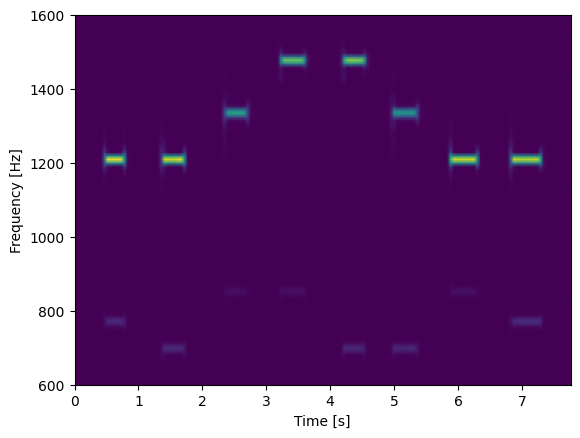

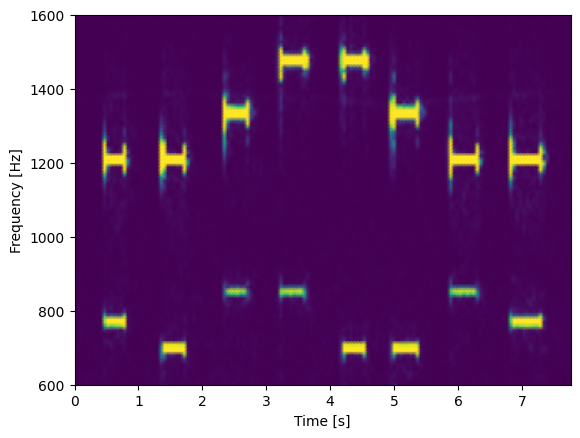

In [57]:

f, t, Zxx = stft(
    audio[:, 0],
    fs=f_s,
    nperseg=5000,
    noverlap=5000/2
)

magnitude = np.abs(Zxx)

plt.pcolormesh(t, f, magnitude, shading="gouraud")
plt.ylim(600, 1600)
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.show()

def sigmoid(x, threshold, steepness=500):
    return 1 / (1 + np.exp(-steepness * (x - threshold)))

plt.pcolormesh(t, f, sigmoid(magnitude, threshold=0.005), shading="gouraud")
plt.ylim(600, 1600)
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.show()

Da frekvenserne mellem 697 og 852 er lave er signalets blevet forstærket og kørt igennem en sigmoid for at forstærke

digits are:
4 1 8 9 3 2 7 4